**Imports**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as st
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 600 # increasing the output plots quality

In [2]:
# Load data
data_df = pd.read_csv("../amz_uk_price_prediction_dataset.csv")

# Create local copy
df = data_df.copy()

## Part 1: Analyzing Best-Seller Trends Across Product Categories

**Objective: Understand the relationship between product categories and their best-seller status.**

**Crosstab Analysis**

In [3]:
# Crosstab between the product category and the isBestSeller status
crosstab_result = pd.crosstab(df["category"], df["isBestSeller"])
crosstab_result

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3
...,...,...
Wind Instruments,243,7
Window Treatments,234,5
Women,17559,213


**Are there categories where being a best-seller is more prevalent?**
- Hint: one option is to calculate the proportion of best-sellers for each category and then sort the categories based on this proportion in descending order.

In [4]:
# Adding a proportion column to the table
crosstab_result["Proportion"] = crosstab_result[True] / (crosstab_result[True] + crosstab_result[False])
crosstab_result

isBestSeller,False,True,Proportion
category,,,
3D Printers,247,1,0.004032
3D Printing & Scanning,4065,2,0.000492
Abrasive & Finishing Products,245,5,0.020000
Action Cameras,1696,1,0.000589
Adapters,251,3,0.011811
...,...,...,...
Wind Instruments,243,7,0.028000
Window Treatments,234,5,0.020921
Women,17559,213,0.011985


In [5]:
# Sorting the table by 'Proportion' in descending order
crosstab_result = crosstab_result.sort_values(by='Proportion', ascending=False)
crosstab_result

isBestSeller,False,True,Proportion
category,,,
Grocery,9008,556,0.058135
Smart Home Security & Lighting,98,6,0.057692
Health & Personal Care,9017,552,0.057686
Mobile Phone Accessories,248,11,0.042471
Power & Hand Tools,8353,306,0.035339
...,...,...,...
"CD, Disc & Tape Players",8798,0,0.000000
General Music-Making Accessories,259,0,0.000000
Snowboard Boots,1449,0,0.000000


As we can see, being a best-seller is more prevalent in the category **'Grocery'.**

**Statistical Tests**

**Chi-square test**

In [6]:
# Perform the Chi-square test
chi2, p, dof, expected = st.chi2_contingency(crosstab_result)

# Display results
print(f"Chi-square statistic: {chi2}")
print(f"P-value: {p}")
print(f"Degrees of freedom: {dof}")
# print("Expected frequencies:\n", expected)

Chi-square statistic: 36684.23786636857
P-value: 0.0
Degrees of freedom: 590


In [7]:
# Interpretation
if p < 0.05:
    print("Reject the null hypothesis: The best-seller status is dependent on the product category.")
else:
    print("Fail to reject the null hypothesis: No significant association between category and best-seller status.")

Reject the null hypothesis: The best-seller status is dependent on the product category.


**Compute Cramér’s V**

In [8]:
# Compute total sample size
n = df.shape[0]

# Compute number of categories (rows) and bestseller statuses (columns)
num_rows, num_cols = crosstab_result.shape

# Compute Cramér’s V
cramers_v = np.sqrt(chi2 / (n * (min(num_rows, num_cols) - 1)))

# Display result
print(f"Cramér's V: {cramers_v}")

# Interpretation:
# - 0.1 = Small effect
# - 0.3 = Medium effect
# - 0.5+ = Large effect

if cramers_v < 0.1:
    print("Cramér's V yields a weak association between the 2 variables.")
if 0.1 < cramers_v < 0.3:
    print("Cramér's V yields a moderate association between the 2 variables.")
if cramers_v > 0.5:
    print("Cramér's V yields a strong association between the 2 variables.")

Cramér's V: 0.08663735048056952
Cramér's V yields a weak association between the 2 variables.


**Visualizations**

**Stacked bar chart** to visualize the relationship between product categories and the best-seller status

**Attention:** To avoid the overlap between bars of all categories in crosstab_result, we select only the first 20 rows.

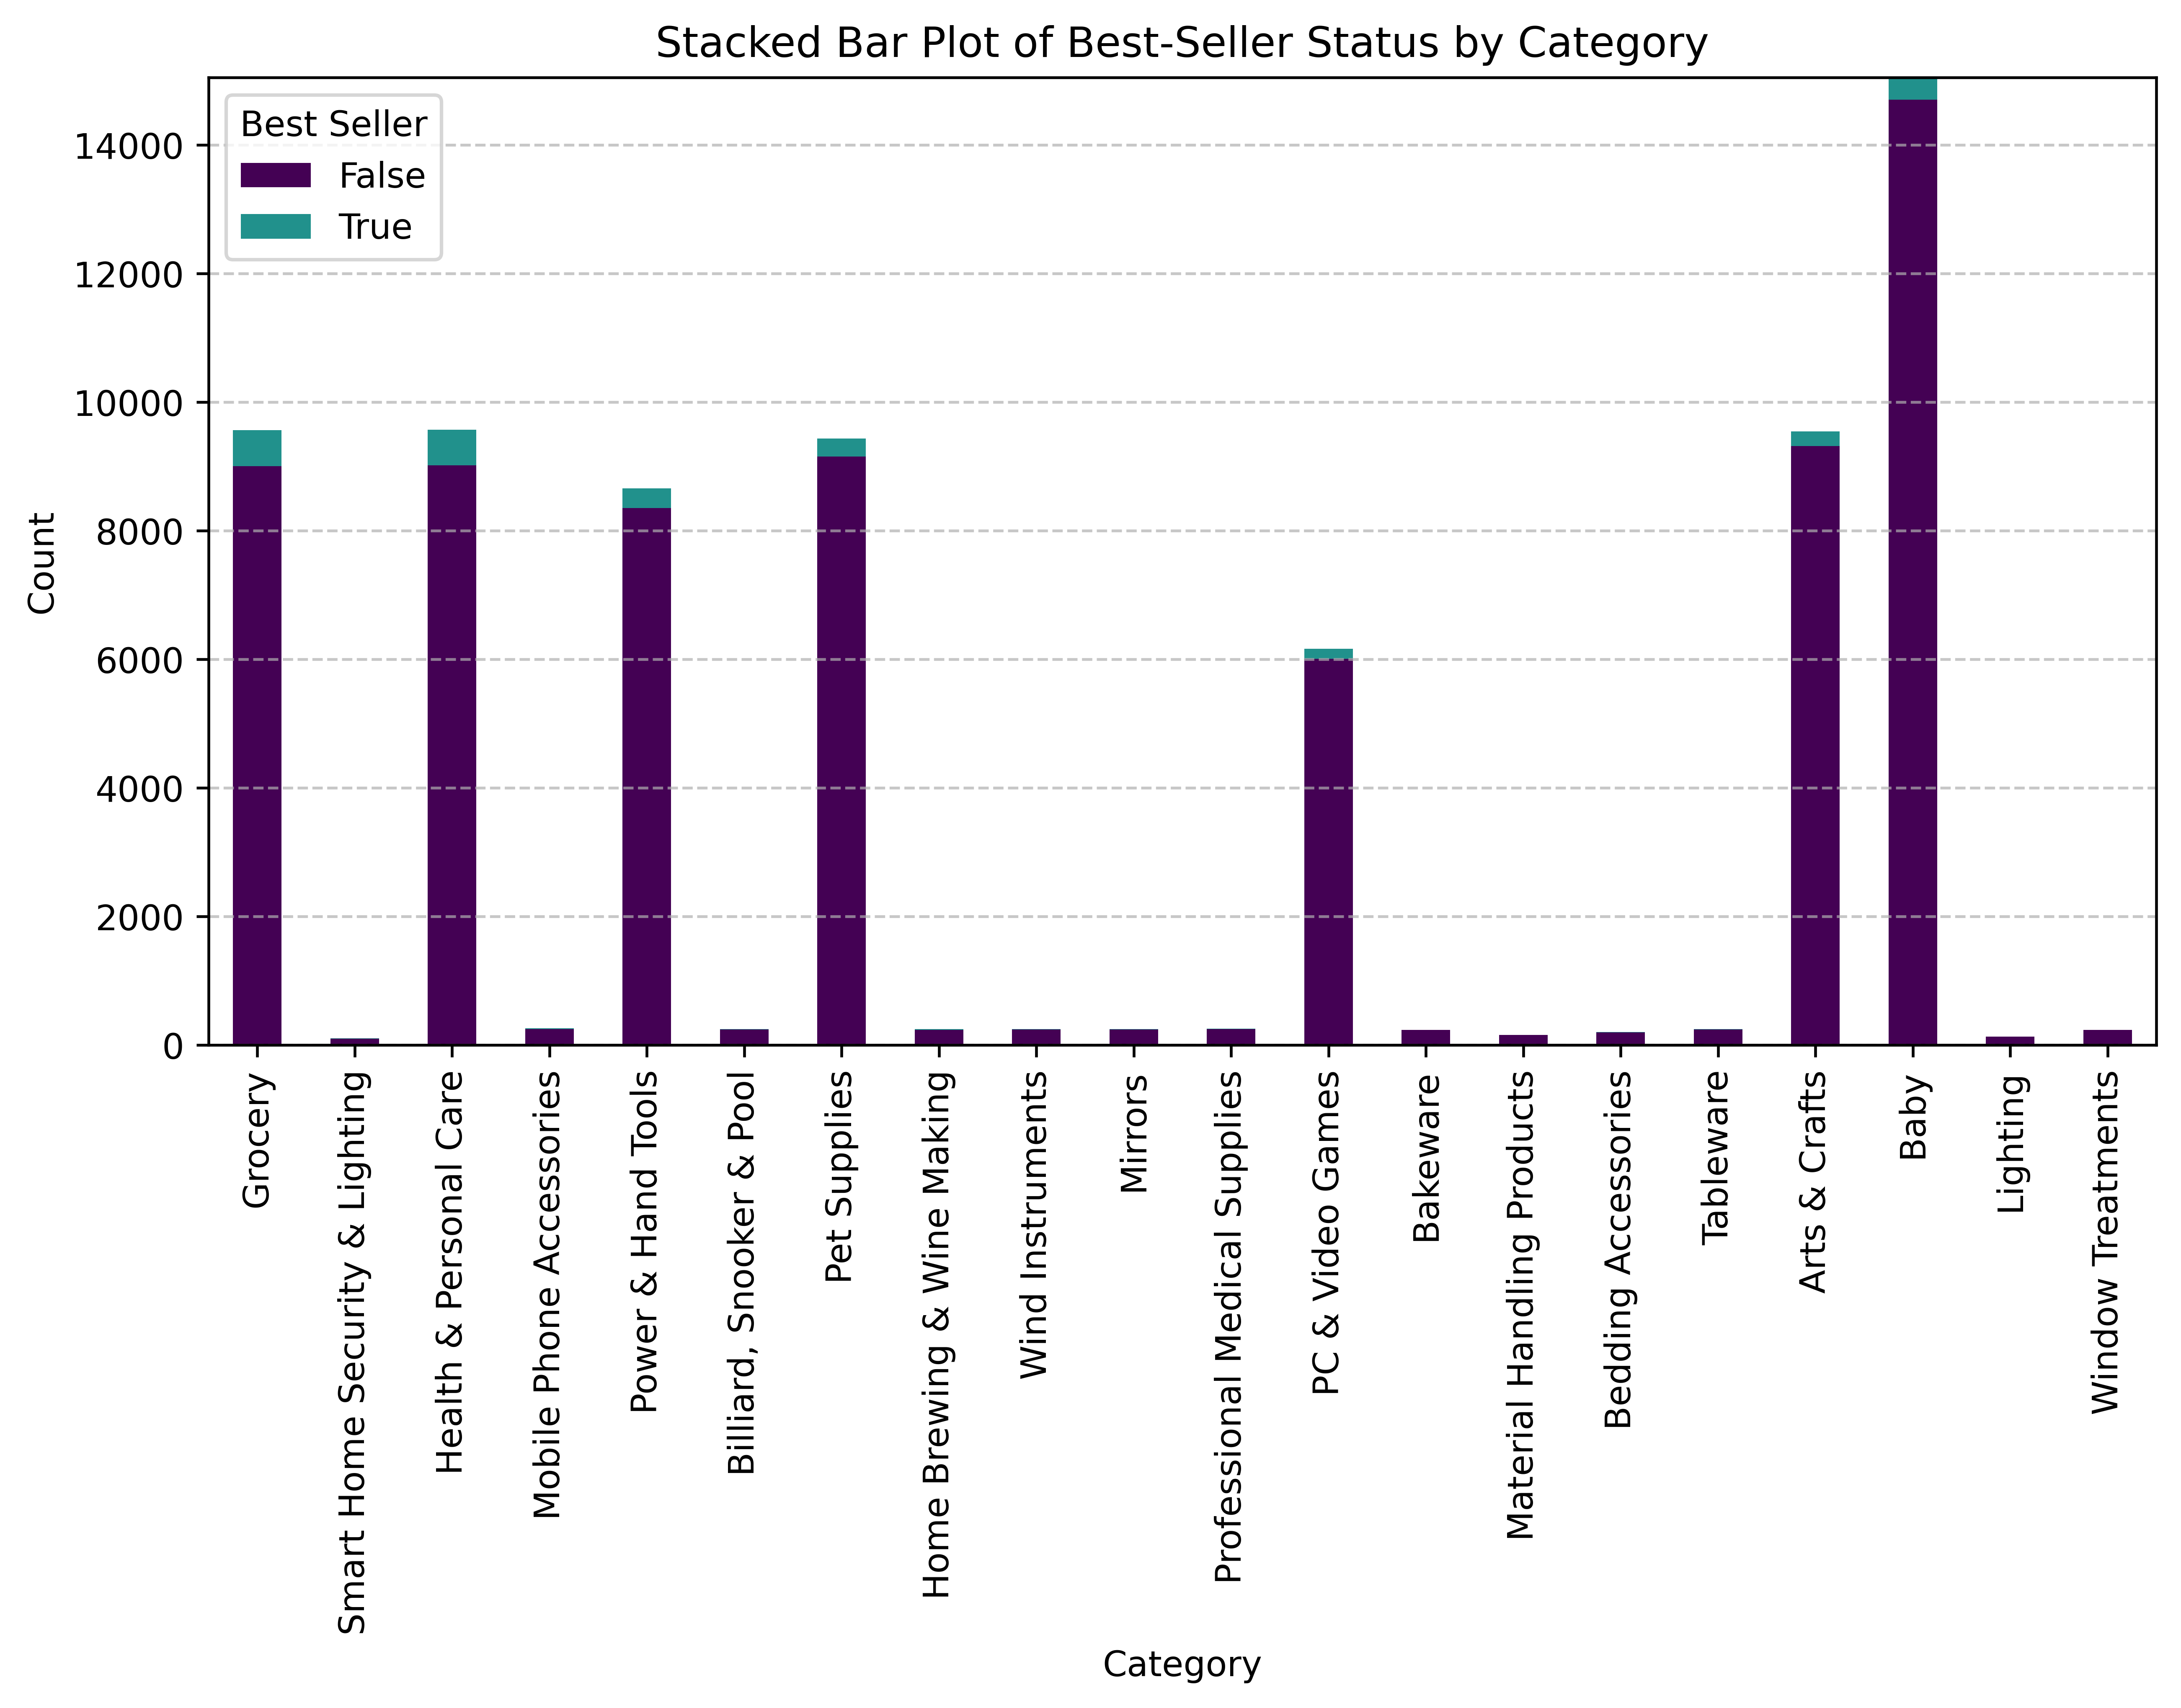

In [9]:
# Plot stacked bar chart
crosstab_result_20 = crosstab_result[:20]
crosstab_result_20.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='viridis')

# Customize labels and title
plt.title("Stacked Bar Plot of Best-Seller Status by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.legend(title="Best Seller", labels=["False", "True"])
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

## Part 2: Exploring Product Prices and Ratings Across Categories and Brands

**Remove outliers in product prices**

**Calculating the quantiles and IQR**

In [10]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Find lower/upper bounds for outliers
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR 

# Filter out the outliers
df_no_outliers = df[(df["price"] >= lower) & (df["price"] <= upper)]

# Optional: Print number of rows before and after removing outliers
print(f"Original rows: {len(df)}")
print(f"Rows after removing outliers: {len(df_no_outliers)}")

Original rows: 2443651
Rows after removing outliers: 2115963


**Violin Plots**

In [11]:
# Filter out the top 20 categories: top_20
top_20 = df["category"].value_counts().head(20).index
top_20

Index(['Sports & Outdoors', 'Beauty', 'Handmade Clothing, Shoes & Accessories',
       'Bath & Body', 'Birthday Gifts', 'Manicure & Pedicure Products',
       'Skin Care', 'Make-up', 'Hair Care', 'Fragrances', 'Handmade Gifts',
       'Handmade Home Décor', 'Luggage and travel gear', 'Handmade Jewellery',
       'Handmade Artwork', 'Women', 'Handmade Home & Kitchen Products',
       'Handmade Kitchen & Dining', 'Men', 'Baby'],
      dtype='object')

**Attention:** For better Visualization, we select the top 5 categories. 

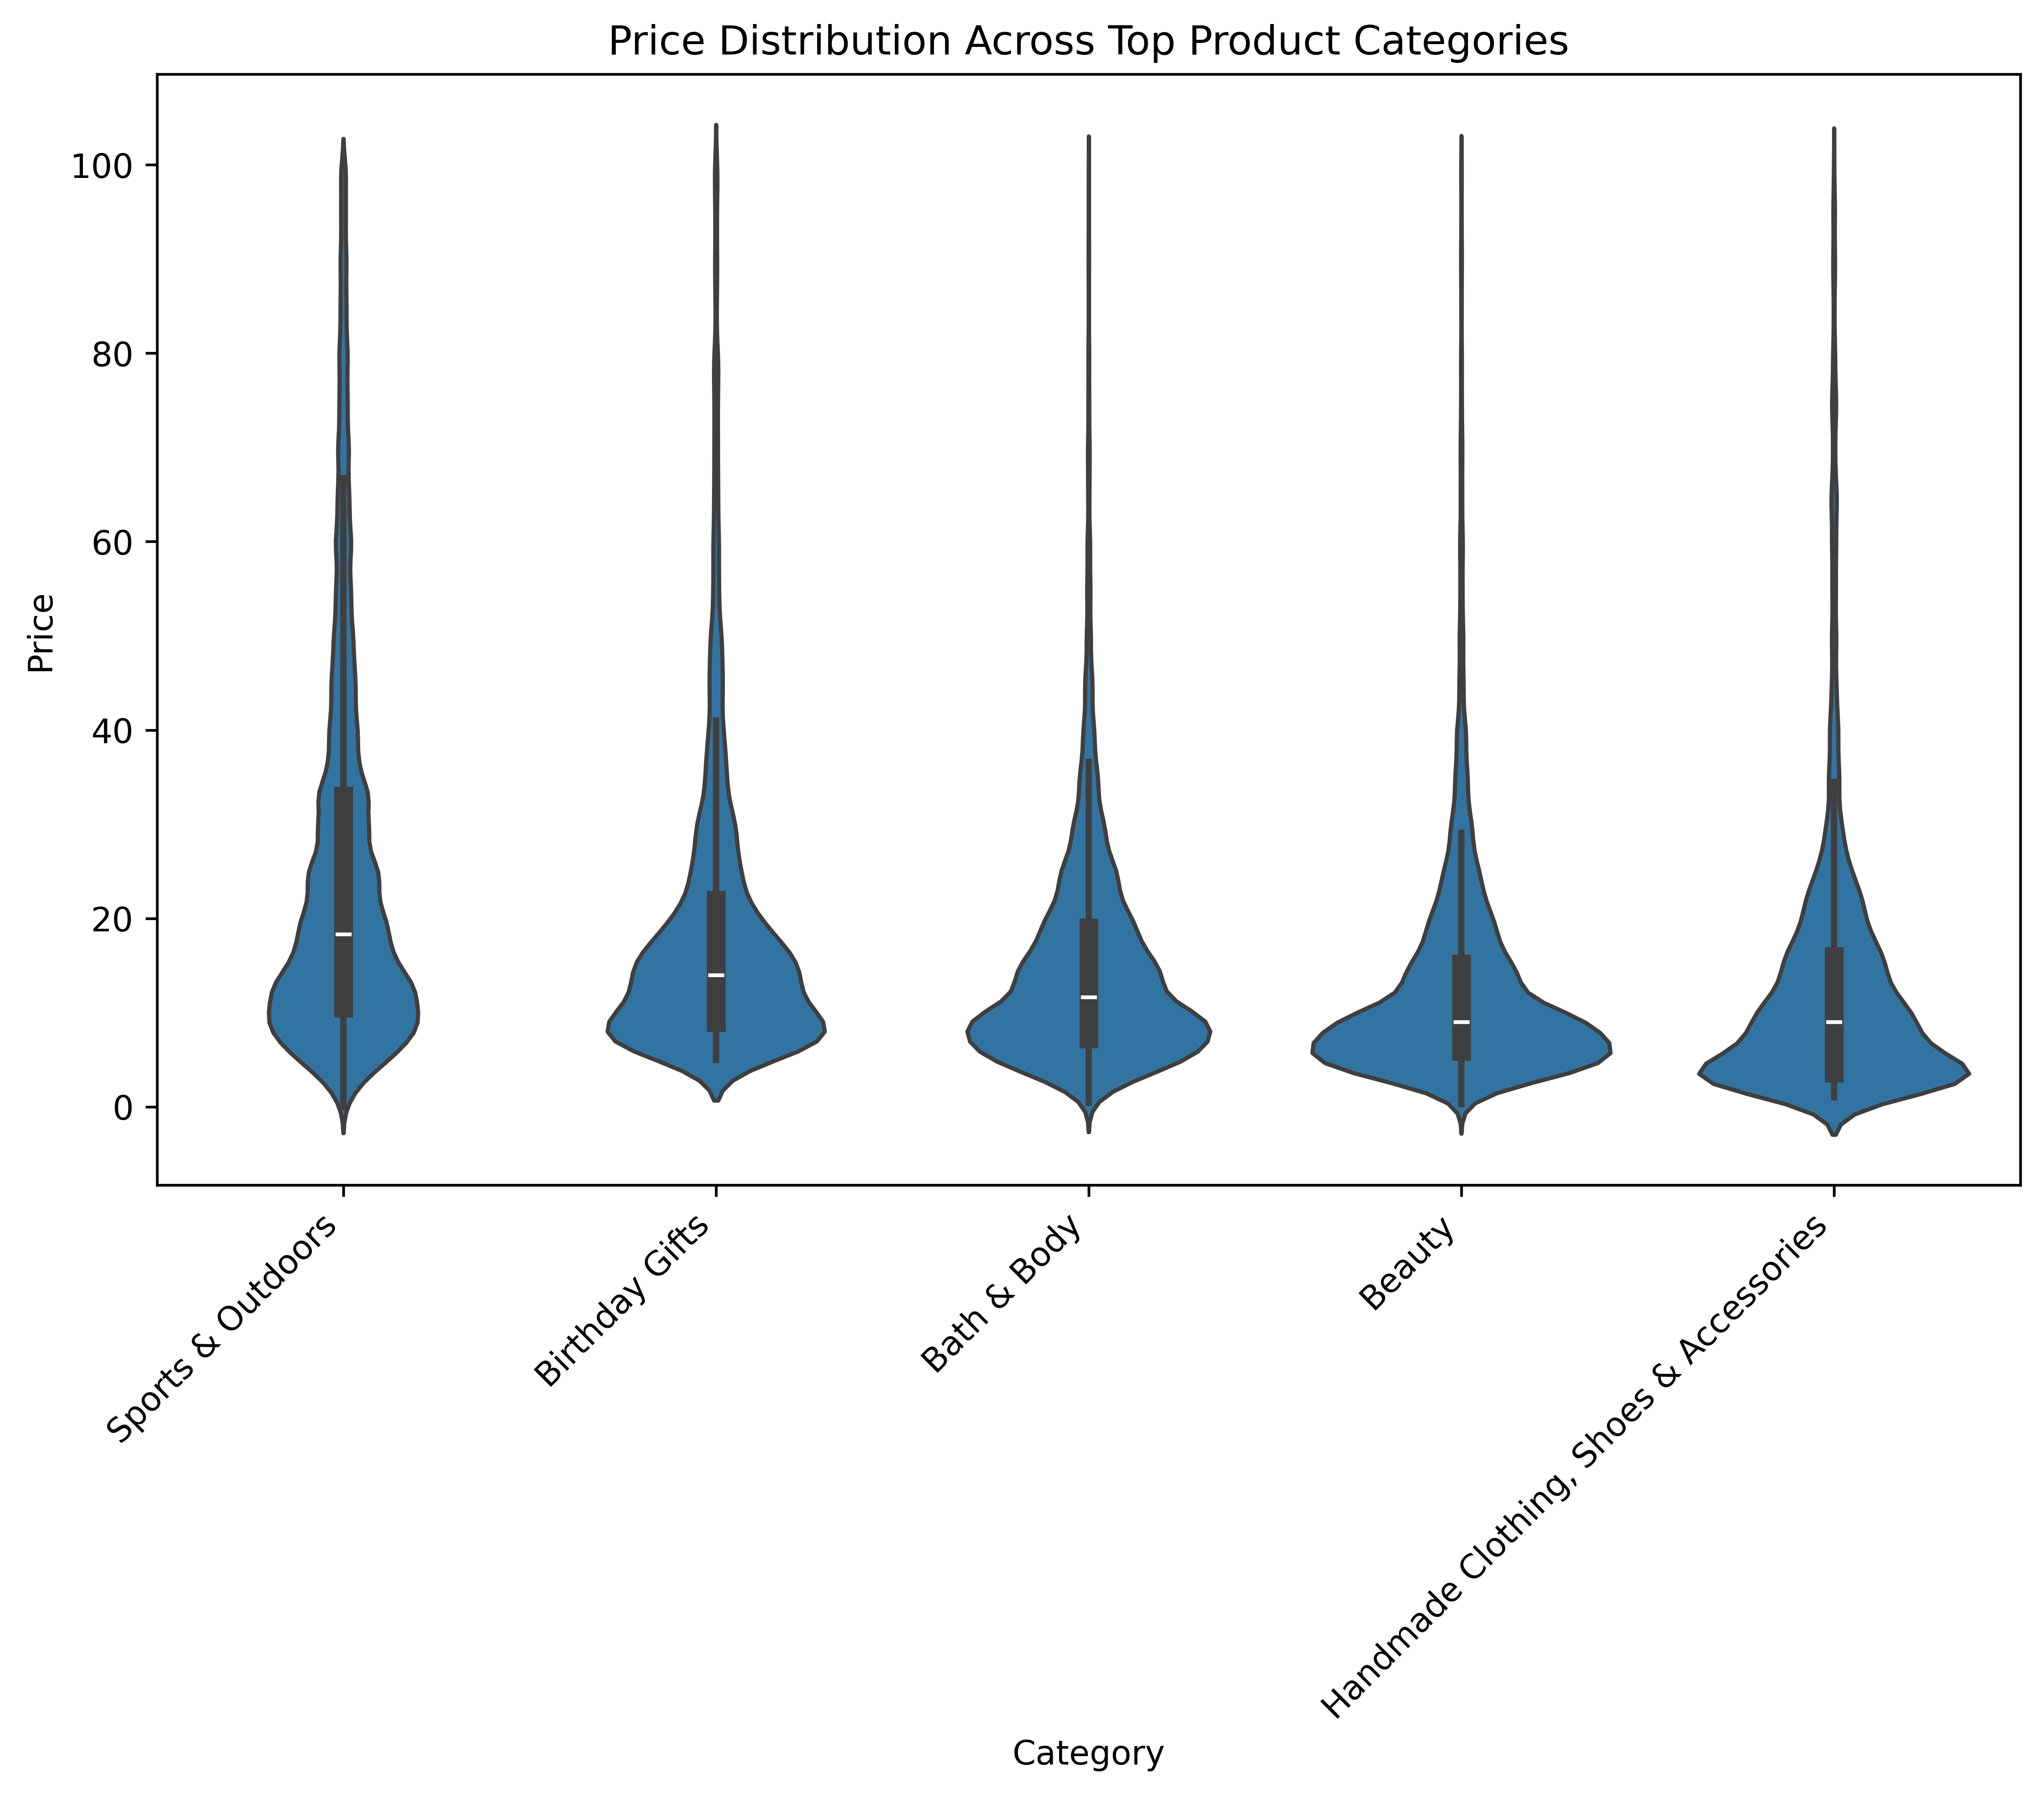

In [12]:
top_5 = df["category"].value_counts().head(5).index
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_no_outliers[df_no_outliers['category'].isin(top_5)], x='category', y='price')
plt.title('Price Distribution Across Top Product Categories')
plt.xlabel('Category')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.show()

**Which product category tends to have the highest median price? Don't filter here by top categories?**

To answer this question, we follow these steps:
- **Group the data** by `category` and calculate the median `price` for each category.
- **Sort** the categories by median price in descending order.
- **Identify** the top category with the highest median price.

In [13]:
# Compute the median price per category
median_prices = df_no_outliers.groupby('category')['price'].median()

# Sort categories by median price in descending order
highest_median_category = median_prices.idxmax()
highest_median_price = median_prices.max()

# Display the result
print(f"Category with the highest median price is {highest_median_category} with ${highest_median_price:.2f}")

# Optional: Display all median prices sorted
median_prices.sort_values(ascending=False)

Category with the highest median price is Desktop PCs with $74.00


category
Desktop PCs              74.00
Boxing Shoes             69.79
Tablets                  69.00
Graphics Cards           68.54
Motherboards             67.92
                         ...  
Adapters                  7.05
Make-up                   7.00
Signs & Plaques           6.99
Arts & Crafts             5.99
Office Paper Products     4.37
Name: price, Length: 296, dtype: float64

**Bar Charts**

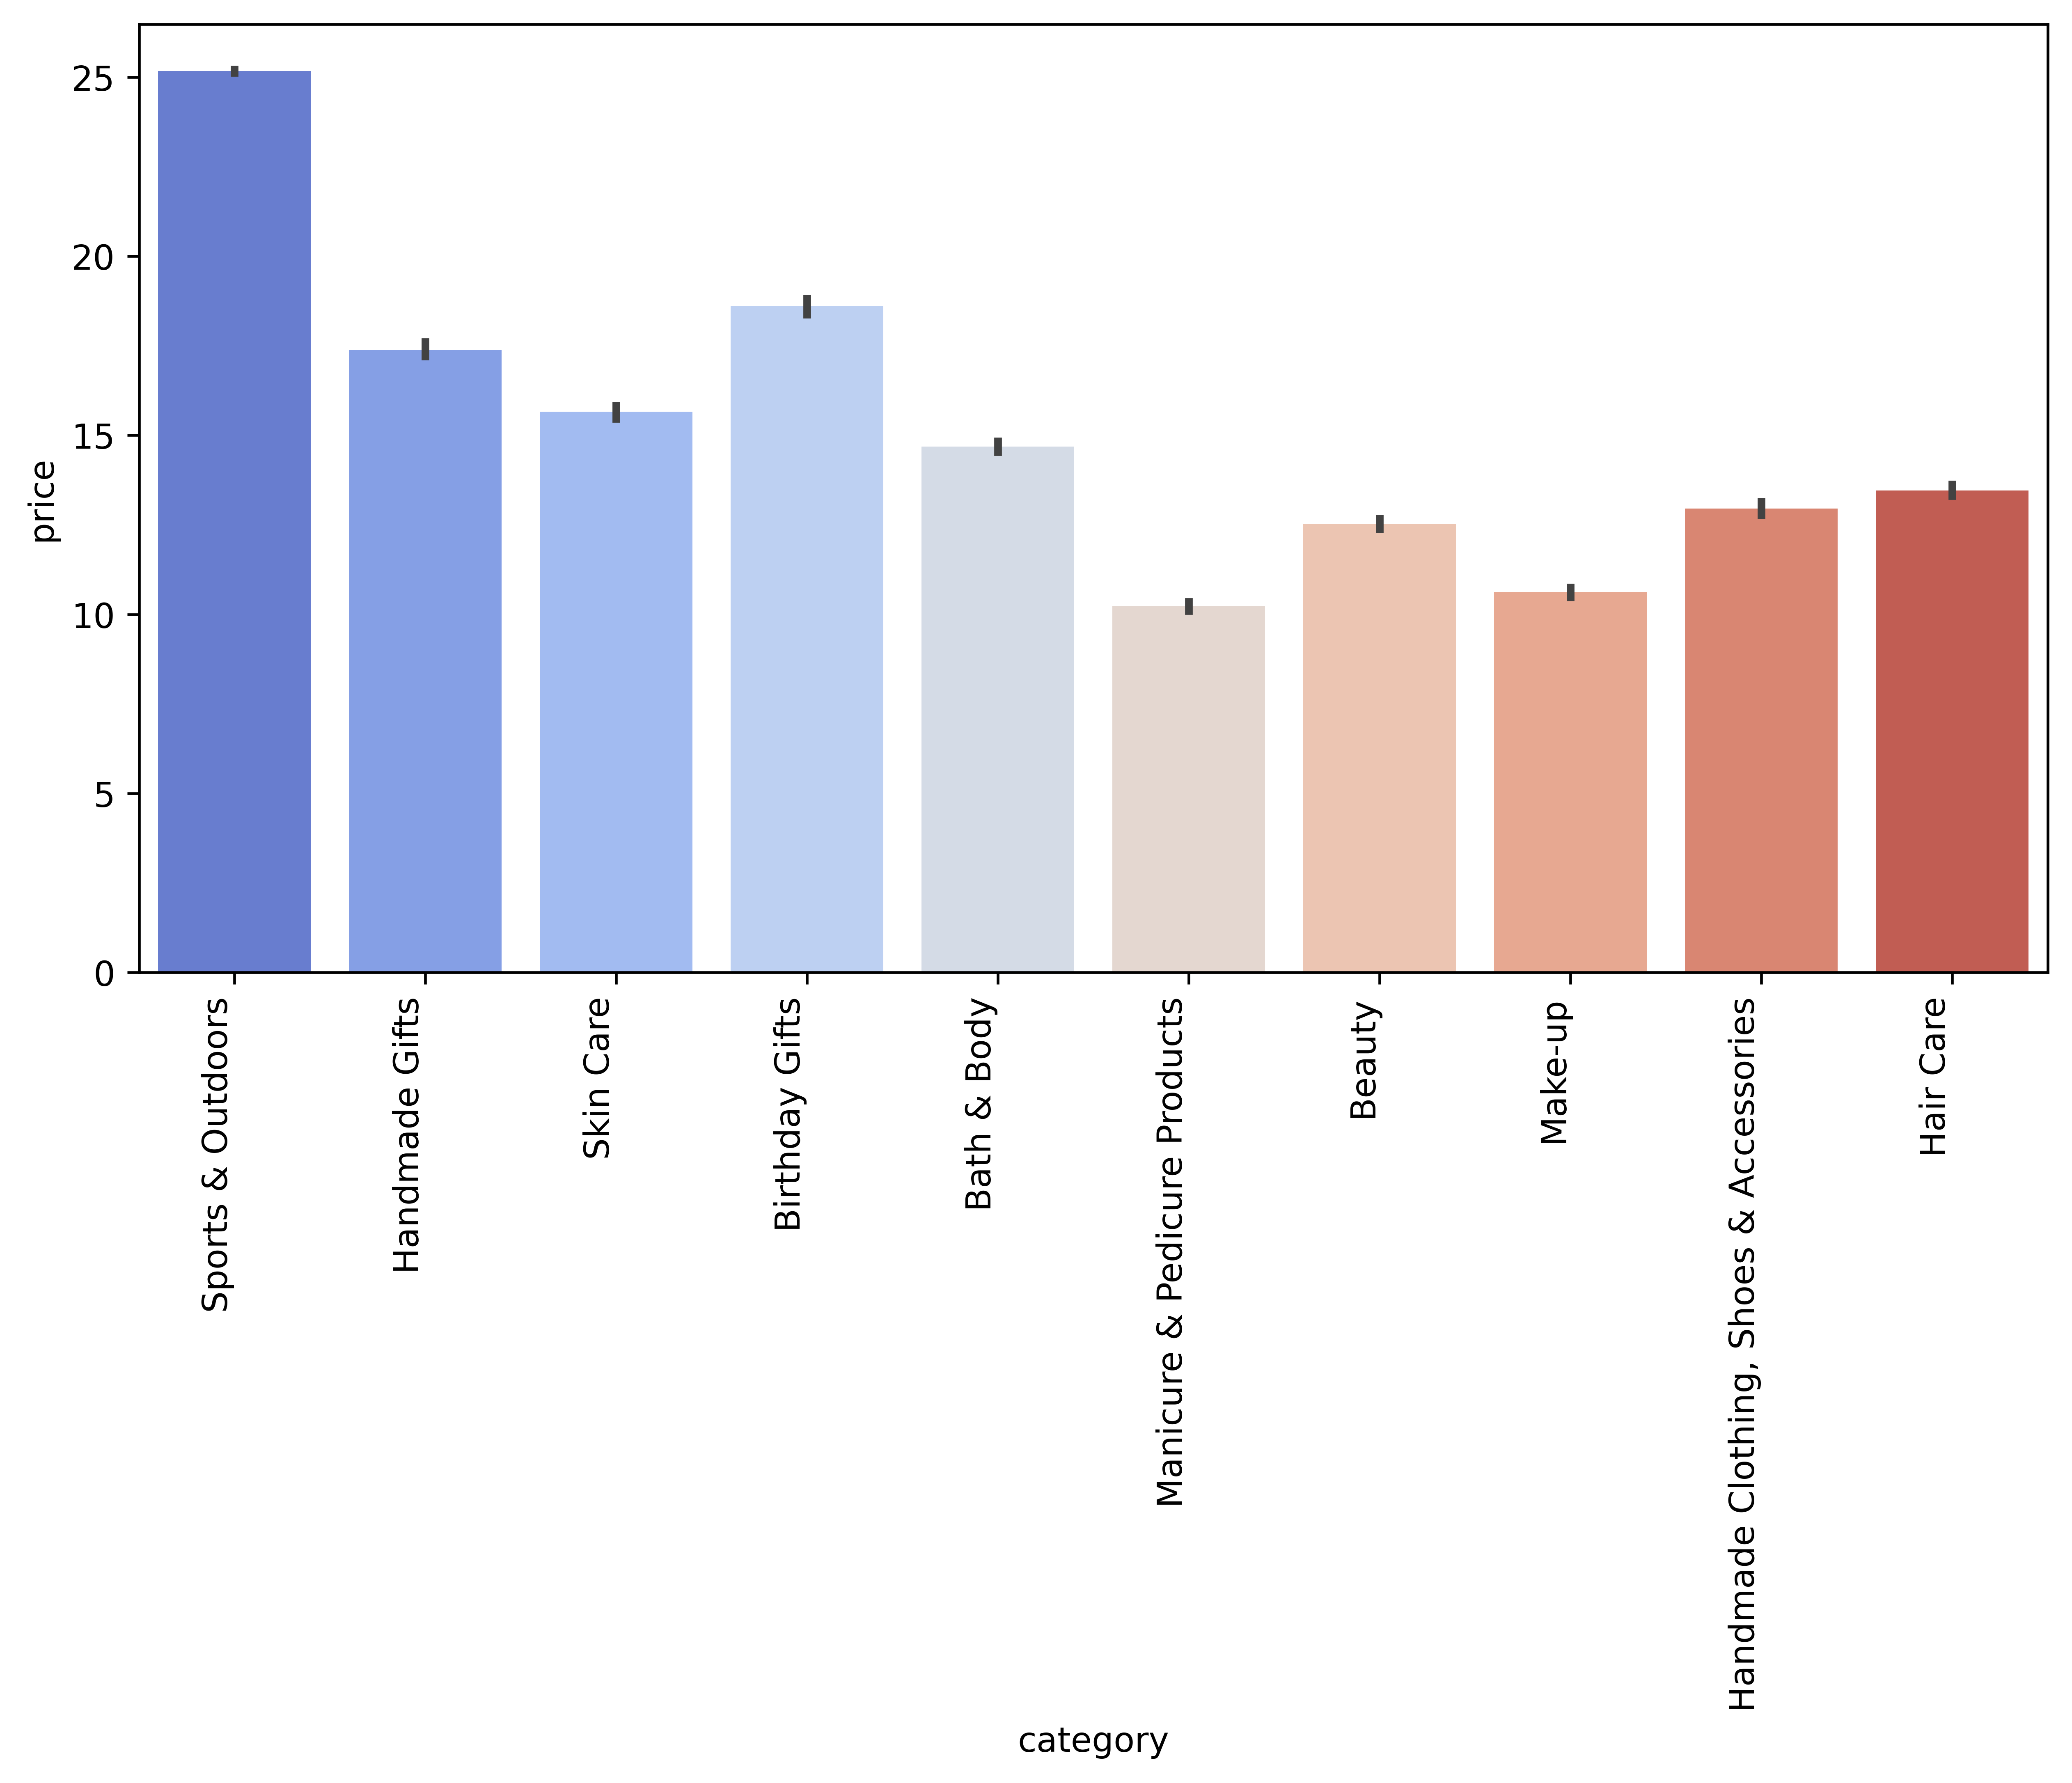

In [14]:
# Get the top 10 most frequent categories
top_10_categories = df_no_outliers["category"].value_counts().head(10).index
df_top_10 = df_no_outliers[df_no_outliers["category"].isin(top_10_categories)]

# Compute the average price per category
avg_prices = df_top_10.groupby('category')['price'].mean().sort_values(ascending=False)

# Plot bar chart
plt.figure(figsize=(10, 5))
sns.barplot(data=df_top_10, x="category", y="price", hue="category", palette="coolwarm", legend=False)
plt.xticks(rotation=90, ha='right')
plt.show()

**Box Plots**

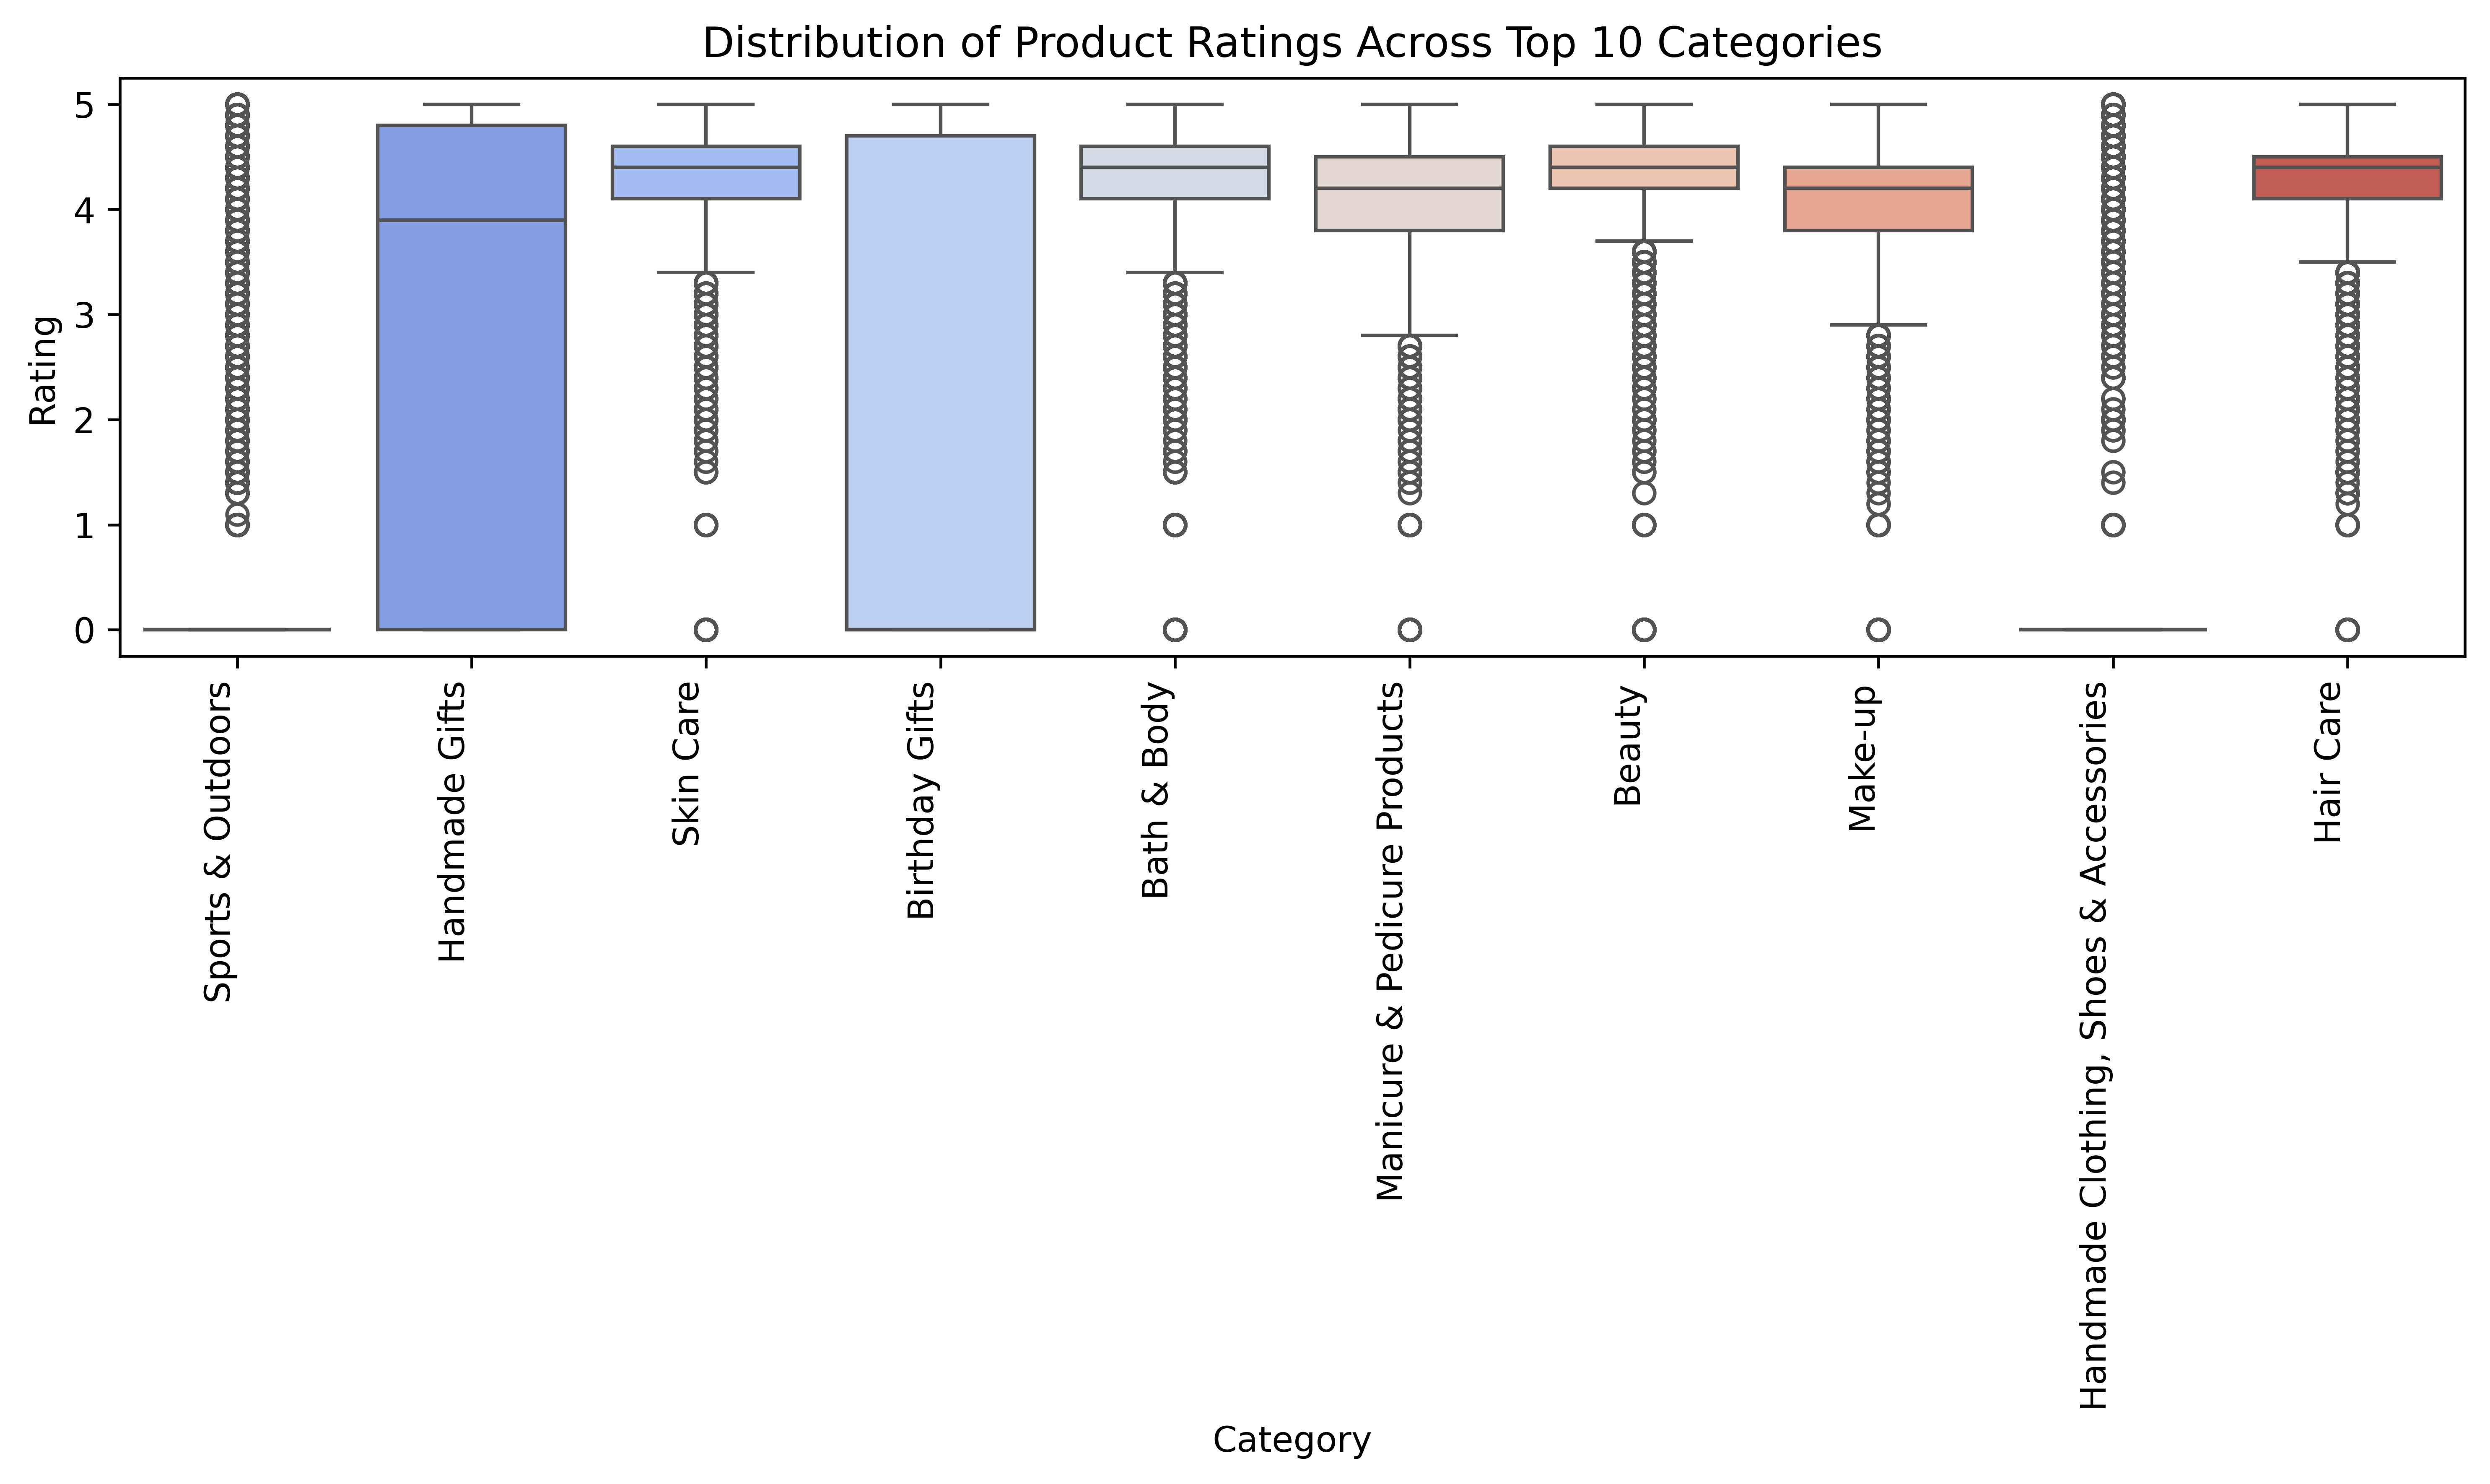

Computer Memory category tends to receive 4.7


In [15]:
# Filter the top 10 categories based on count for the box plot visualization
top_10_categories = df_no_outliers['category'].value_counts().head(10).index

# Visualize the distribution of product ratings across the top 10 categories
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_no_outliers[df_no_outliers['category'].isin(top_10_categories)], x='category', y='stars', hue='category', palette="coolwarm", legend=False)
plt.title('Distribution of Product Ratings Across Top 10 Categories')
plt.xlabel('Category')
plt.ylabel('Rating')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

# Calculate the median rating for each category
category_median_ratings = df.groupby('category')['stars'].median()

# Find the category with the highest median rating
highest_median_category = category_median_ratings.idxmax()
highest_median_rating = category_median_ratings.max()

print(f"{highest_median_category} category tends to receive {highest_median_rating}")

## Part 3: Investigating the Interplay Between Product Prices and Ratings

**Correlation Coefficients**

In [16]:
# Pearson correlation coefficient between price and stars
p_corrcoef = float(df_no_outliers['price'].corr(df_no_outliers['stars']))
print("Pearson Correlation between Price and Stars is: ", p_corrcoef)

# Spearman correlation coefficient between price and stars
s_corrcoef = float(df_no_outliers['price'].corr(df_no_outliers['stars'], method="spearman"))
print("Spearman Correlation between Price and Stars is: ", s_corrcoef)

Pearson Correlation between Price and Stars is:  -0.07767299878181444
Spearman Correlation between Price and Stars is:  -0.06679697280768455


**Both show a small negative correlation telling us that `price` and `stars` (ratings) are slightly moving against each other**

**Visualizations**

**Scatter Plot** to visualize the relationship between product rating and price

**Attention:** For better visualization, we select the first 1000 rows of the original DataFrame 

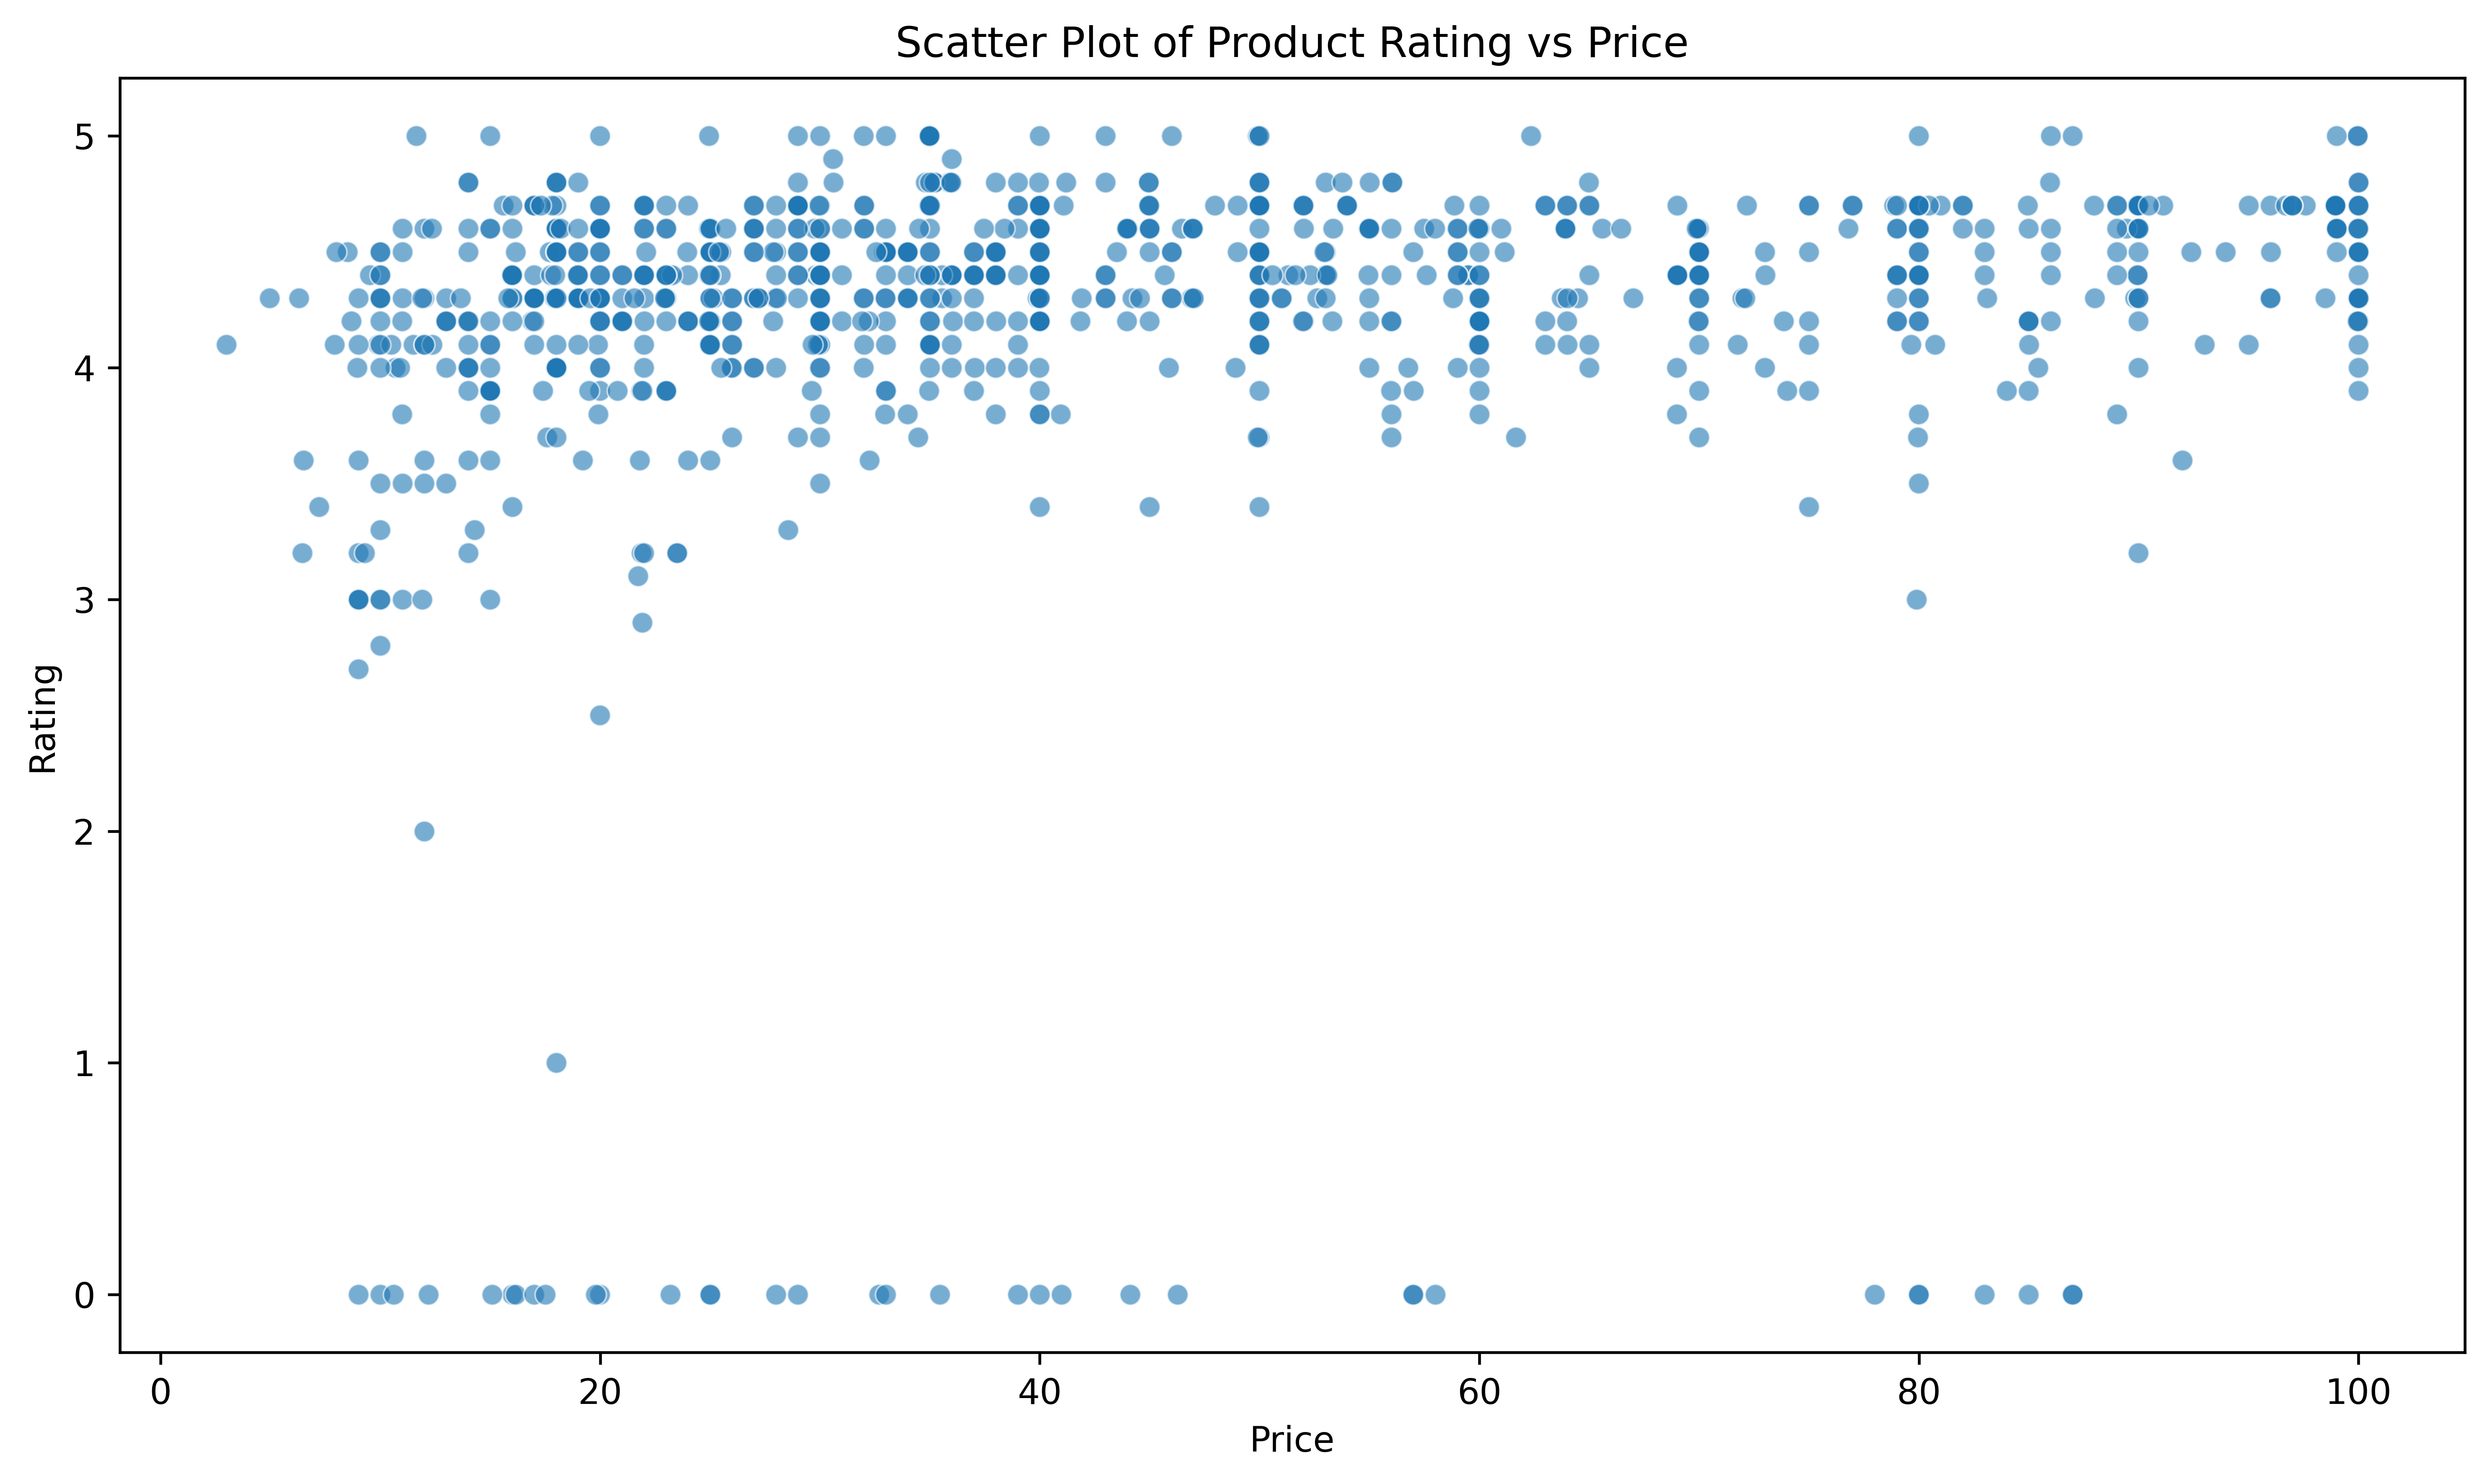

In [17]:
df_1k = df_no_outliers[:1000] # selecting the first 1000 rows from df

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_1k, x='price', y='stars', alpha=0.6)
plt.title('Scatter Plot of Product Rating vs Price')
plt.xlabel('Price')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

**As we can see, the scatter plot doesn't follow any well-known distribution such as normal**

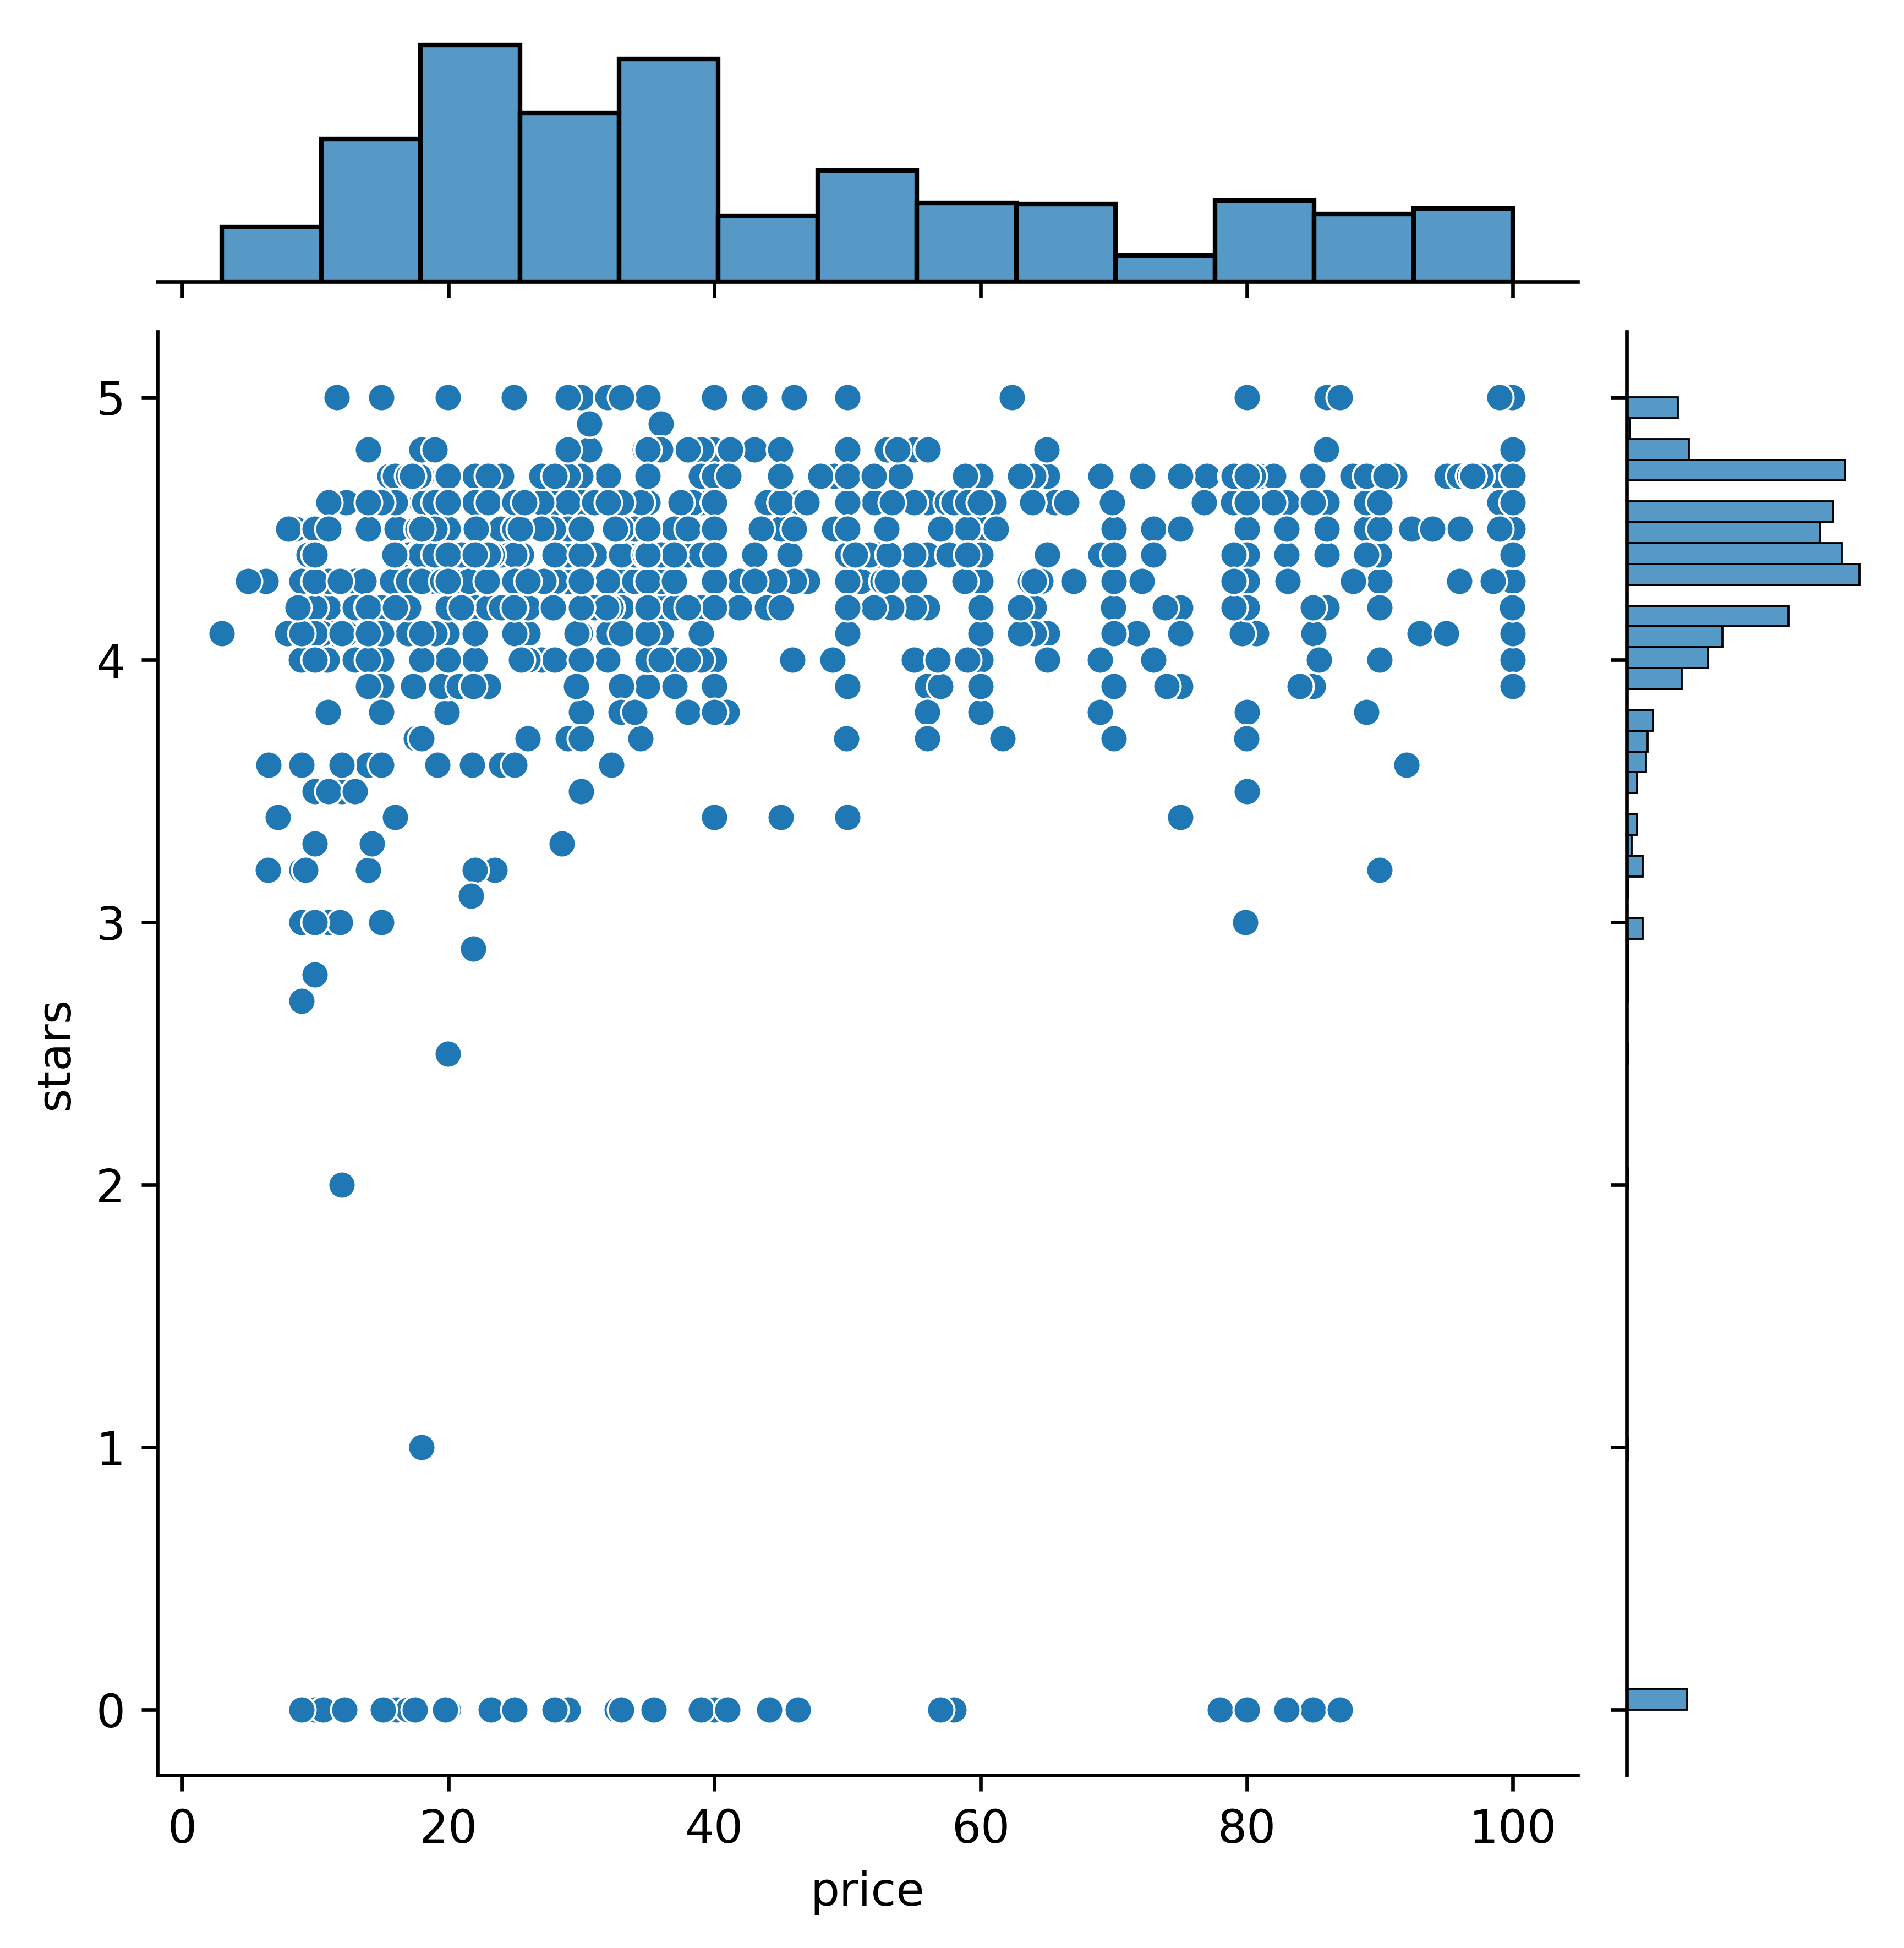

In [18]:
sns.jointplot(y=df_1k['stars'], x=df_1k['price'])
plt.show()

**Divide DataFrame into categorical and numerical values**

In [19]:
df_cat = df_no_outliers.select_dtypes(exclude="number")
df_num = df_no_outliers.select_dtypes(include="number")

**Correlation matrix**

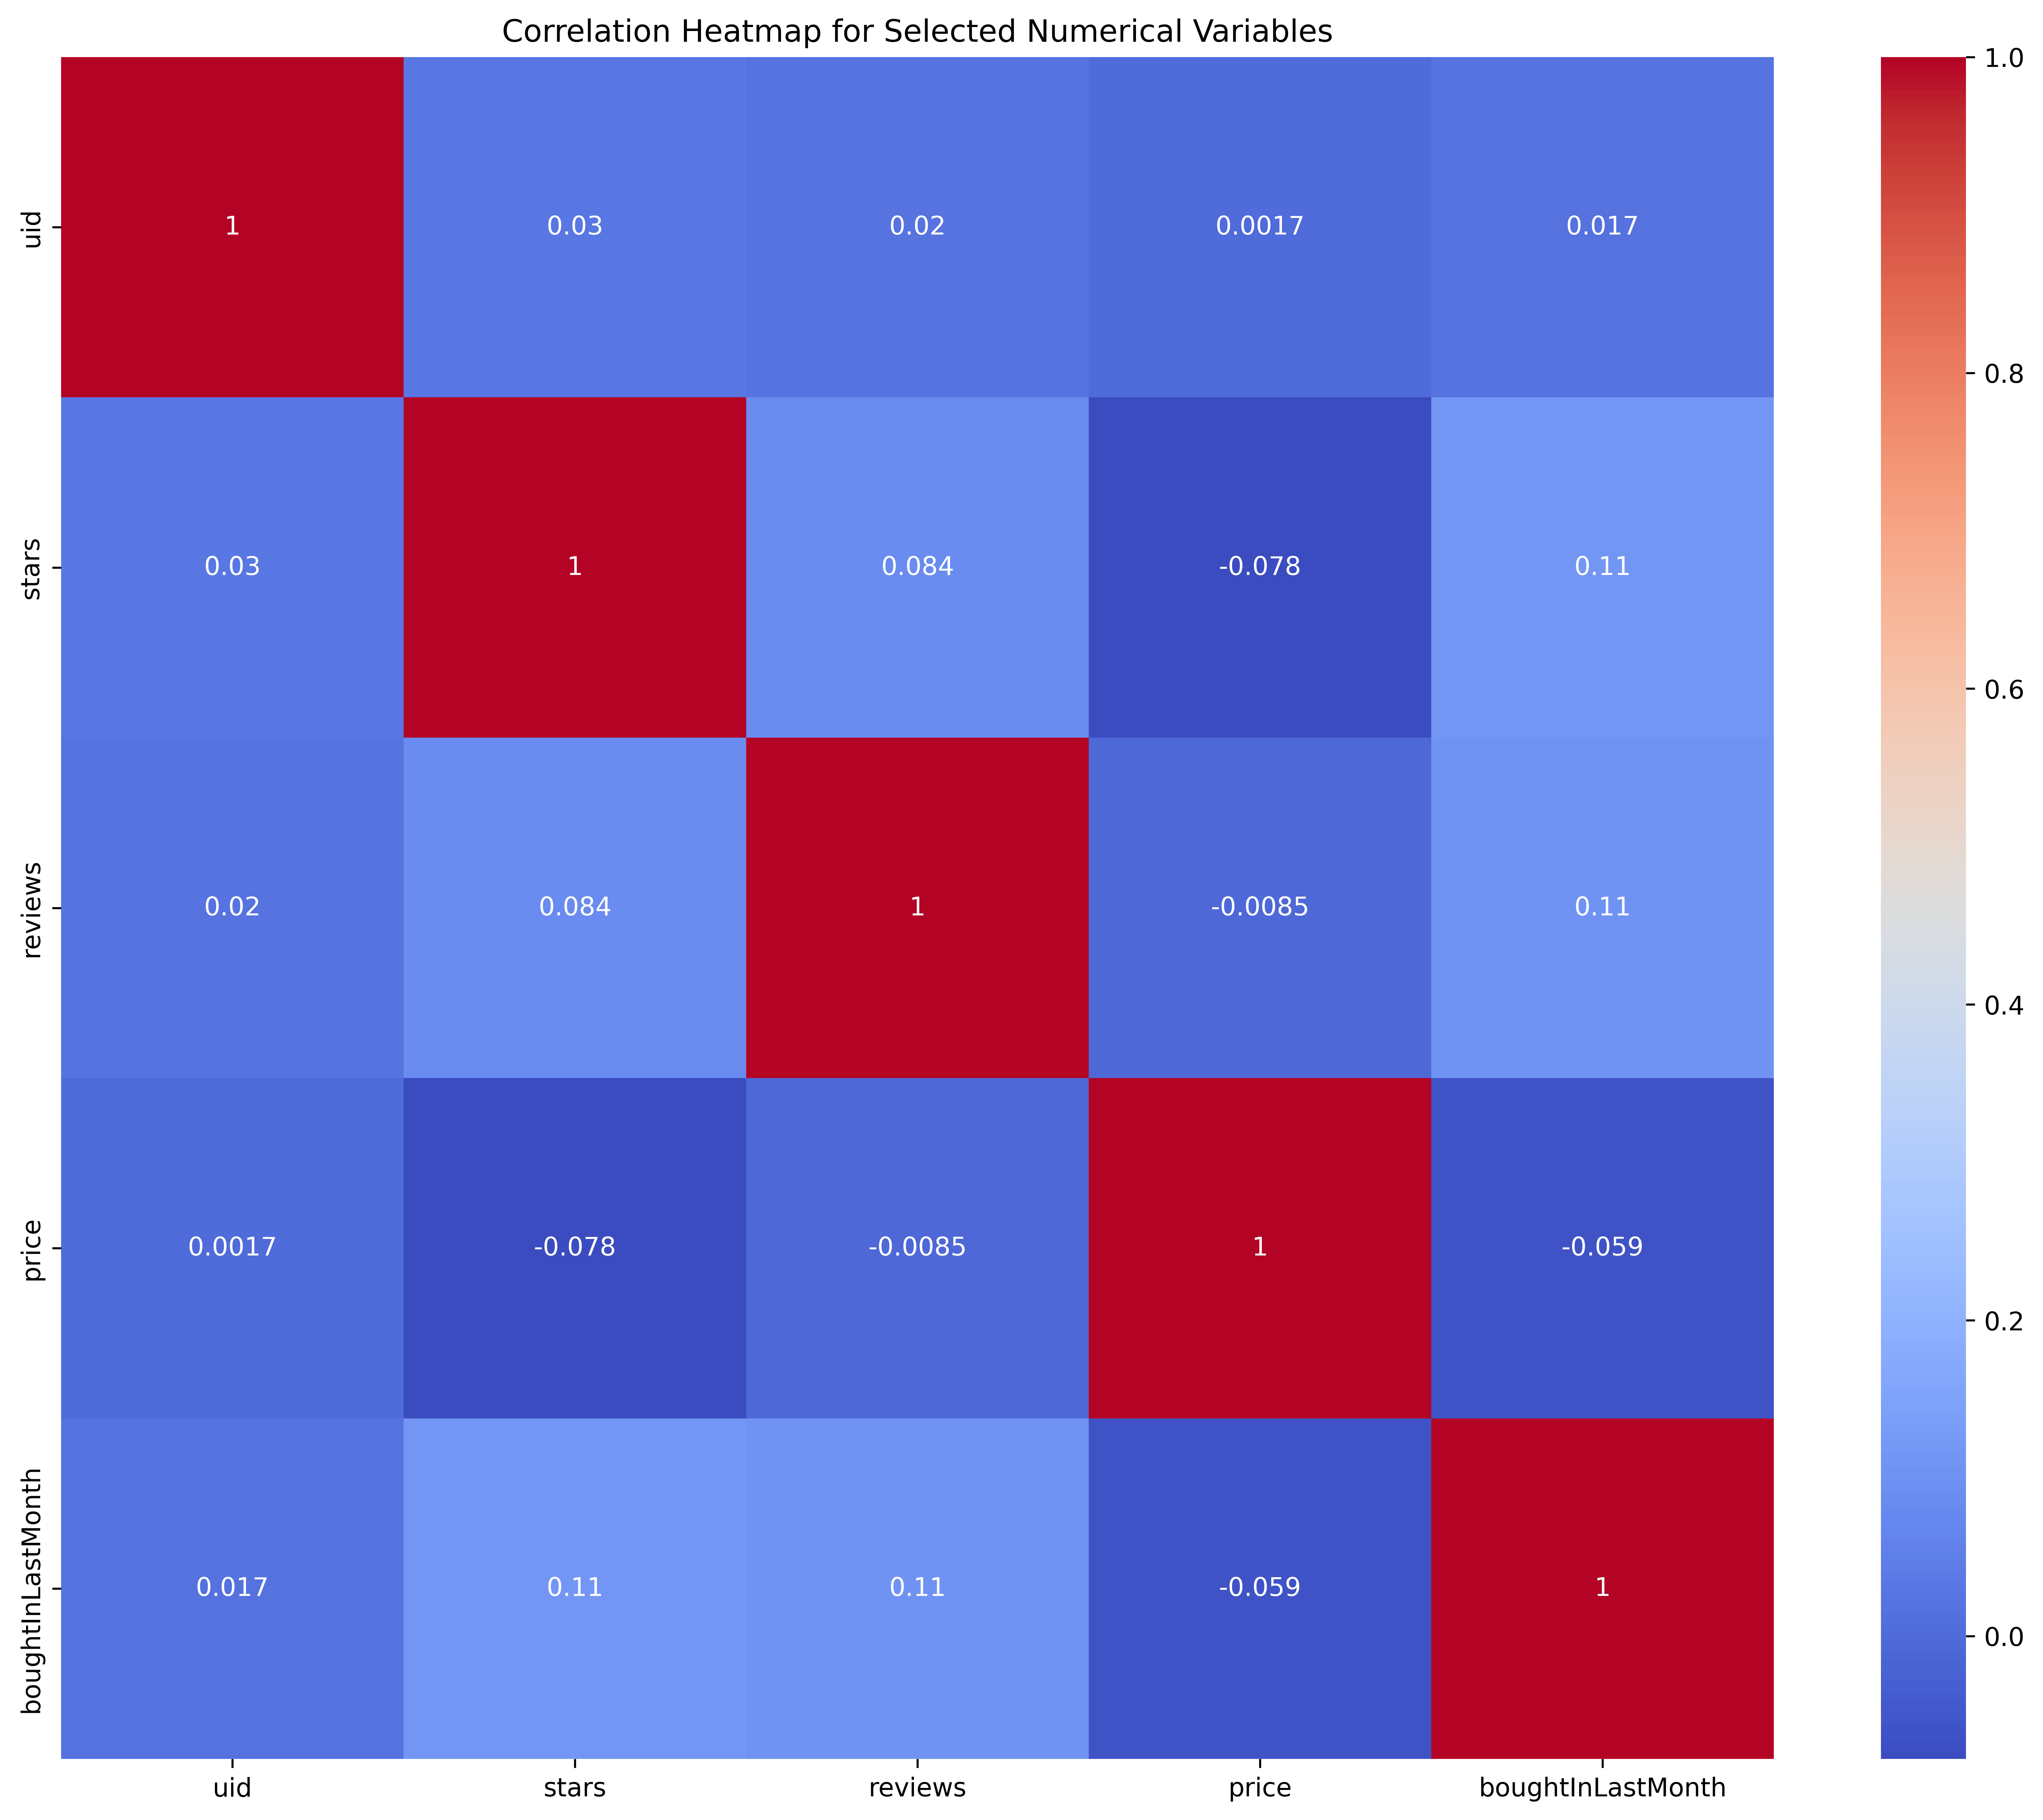

In [20]:
# Define the correlation matrix
correlation_matrix = df_num.corr()

# Set up the figsize
plt.figure(figsize=(15, 12))

# Plot heatmap for numerical columns
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")

# Add title
plt.title("Correlation Heatmap for Selected Numerical Variables")
plt.show()

**QQ Plot** to see if prices follow a normal distribution

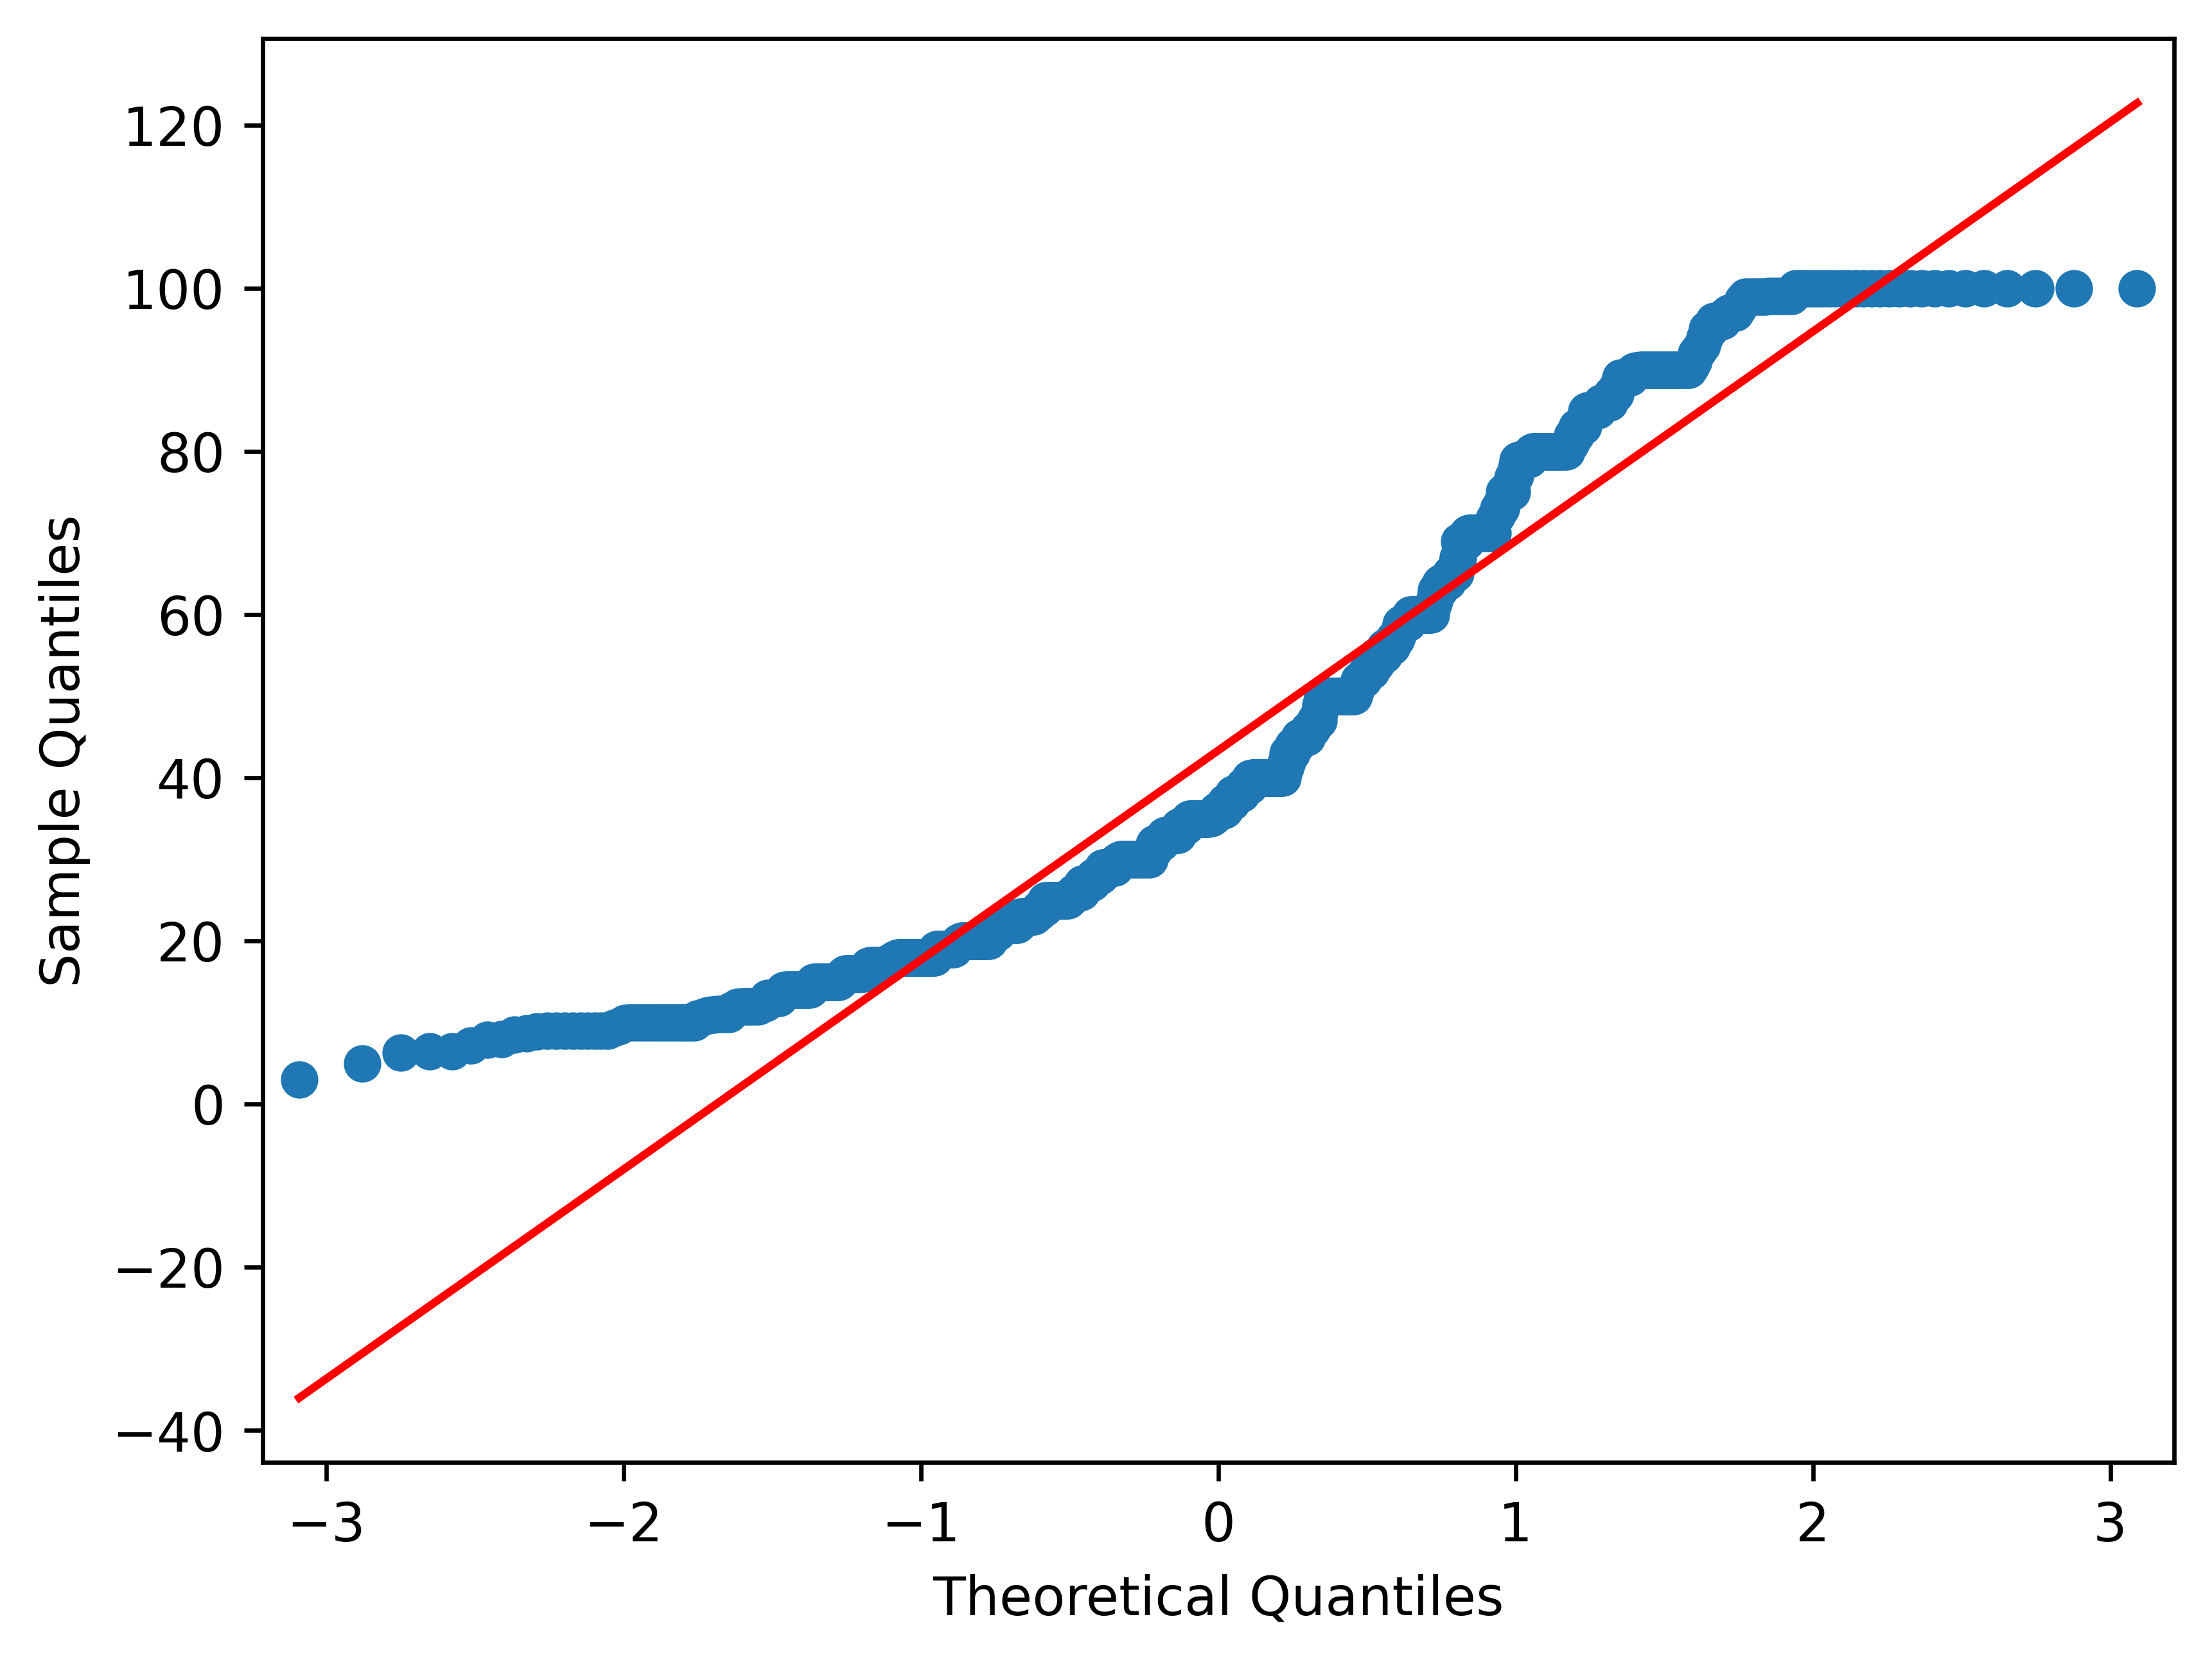

In [21]:
import statsmodels.api as sm

# Generating a Q-Q plot for price column to see if it follows a normal distribution
sm.qqplot(df_1k['price'], line='s')
plt.show()

**As we can see, price doesn't follow a normal distributon**